# Multitask Shapes – interactive play  
  
This notebook lets you **play the customised “Multitask Shapes” environment** that you pasted.  
At each step you’ll be asked for an action:

| index | meaning  |
|-------|----------|
| 0     | **UP**   |
| 1     | **DOWN** |
| 2     | **LEFT** |
| 3     | **RIGHT**|
| 4     | **PICK** |
| 5     | **DROP** |

The notebook will  
* execute the action,  
* print the new reward & raw observation, and  
* display the rendered frame.

> **Prerequisites**  
> * `shapes.py`, `multitask_shapes.py`, `utils.py`, the `assets/` folder and your YAML hyper‑parameter file must be provided.
> * Python ≥ 3.9 with the packages in the first code‑cell installed.


In [1]:
# ------------------------------------------------------------
# (Optional) install runtime dependencies
# ------------------------------------------------------------
# If you are missing any of these packages, remove the leading
# '#' and run the cell once.
#
# !pip install -q gymnasium numpy opencv-python-headless matplotlib pyyaml


In [1]:
# ------------------------------------------------------------
# Imports & utility helpers
# ------------------------------------------------------------
import os, yaml, numpy as np, cv2, matplotlib.pyplot as plt
from typing import Dict
from IPython.display import clear_output
import time

# Adjust the import below if your python file has a different name
from envs.shapes.multitask_shapes import ShapesAttrCombFactory
from envs.shapes.shapes import RND_FTR_RNG
from utils import setup_artefact_paths

# Helper to display a rendered frame inline
def show_frame(img):
    plt.figure(figsize=(4,4))
    # convert BGR (OpenCV) ➜ RGB (matplotlib)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

def _category_range(features: Dict, category: str) -> int:
    rng = len(features[category])
    if category == "shape" and "door" in features[category]:
        rng -= 1
    return rng

def infer_obs_layout(obs: np.ndarray, features: Dict, n_objs: int, n_doors: int, n_cnfd_vars: int):
    colour_rng = _category_range(features, "colour")
    shape_rng = _category_range(features, "shape")

    raw_obj_ftrs = 5 + n_cnfd_vars
    raw_door_ftrs = 4 + n_cnfd_vars
    onehot_obj_ftrs = 2 + colour_rng + shape_rng + 1 + n_cnfd_vars * RND_FTR_RNG
    onehot_door_ftrs = 2 + colour_rng + 1 + n_cnfd_vars * RND_FTR_RNG

    raw_total = n_objs * raw_obj_ftrs + n_doors * raw_door_ftrs + 2
    onehot_total = n_objs * onehot_obj_ftrs + n_doors * onehot_door_ftrs + 2

    if obs.size == onehot_total:
        one_hot_obs = True
        num_obj_ftrs = onehot_obj_ftrs
        num_door_ftrs = onehot_door_ftrs
    elif obs.size == raw_total:
        one_hot_obs = False
        num_obj_ftrs = raw_obj_ftrs
        num_door_ftrs = raw_door_ftrs
    else:
        raise ValueError(f"Unexpected observation size {obs.size}. Expected {raw_total} (raw) or {onehot_total} (one-hot).")

    door_start_idx = n_objs * num_obj_ftrs
    agent_start_idx = door_start_idx + n_doors * num_door_ftrs

    return {
        "one_hot_obs": one_hot_obs,
        "colour_rng": colour_rng,
        "shape_rng": shape_rng,
        "num_obj_ftrs": num_obj_ftrs,
        "num_door_ftrs": num_door_ftrs,
        "n_objs": n_objs,
        "n_doors": n_doors,
        "door_start_idx": door_start_idx,
        "agent_start_idx": agent_start_idx,
    }

def _decode_scalar_or_onehot(vec: np.ndarray, idx: int, width: int, one_hot_obs: bool):
    if one_hot_obs:
        return int(np.argmax(vec[idx:idx + width])) + 1, idx + width
    return int(vec[idx]), idx + 1

def semantically_interpretable_state(obs: np.ndarray, features: Dict, layout: Dict):
    door_idx_0 = layout["door_start_idx"]
    agent_idx_0 = layout["agent_start_idx"]
    num_obj_ftrs = layout["num_obj_ftrs"]
    num_door_ftrs = layout["num_door_ftrs"]
    num_objs = layout["n_objs"]
    num_doors = layout["n_doors"]
    one_hot_obs = layout["one_hot_obs"]

    print(f"Agent is at {obs[agent_idx_0]}, {obs[agent_idx_0+1]}.")

    obj_rows = obs[:door_idx_0].reshape(num_objs, num_obj_ftrs)
    for obj_row in obj_rows:
        obj_x = int(obj_row[0])
        obj_y = int(obj_row[1])
        cursor = 2
        obj_clr_ftr, cursor = _decode_scalar_or_onehot(obj_row, cursor, layout["colour_rng"], one_hot_obs)
        obj_shape_ftr, cursor = _decode_scalar_or_onehot(obj_row, cursor, layout["shape_rng"], one_hot_obs)
        obj_picked_up = int(obj_row[cursor])

        obj_clr_str = features["colour"][obj_clr_ftr - 1]
        obj_shape_str = features["shape"][obj_shape_ftr - 1]
        semantic_str = f"{obj_clr_str} {obj_shape_str} at {obj_x}, {obj_y}."
        if obj_picked_up:
            semantic_str += " Object in inventory."
        print(semantic_str)

    door_rows = obs[door_idx_0:agent_idx_0].reshape(num_doors, num_door_ftrs)
    for door_row in door_rows:
        door_x = int(door_row[0])
        door_y = int(door_row[1])
        cursor = 2
        door_clr_ftr, cursor = _decode_scalar_or_onehot(door_row, cursor, layout["colour_rng"], one_hot_obs)
        door_locked = int(door_row[cursor])

        door_clr_str = features["colour"][door_clr_ftr - 1]
        semantic_str = f"{door_clr_str} door at {door_x}, {door_y} is "
        if door_locked:
            semantic_str += "locked."
        else:
            semantic_str += "unlocked."
        print(semantic_str)
        

/home/djordje/miniconda3/envs/rlexp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ------------------------------------------------------------
# Load hyper‑parameters & create the environment
# ------------------------------------------------------------
parent_dir = os.path.dirname(os.getcwd())
# Fill yaml_path as desired, the rest should work as is.
yaml_path = os.path.join(parent_dir, "envs", "shapes", "configs", "shapes_lin.yaml")

script_path = os.path.join(os.getcwd(), 'shapes_play.ipynb')
store_path, _ = setup_artefact_paths(script_path)

with open(yaml_path, 'r') as f:
    hparams = yaml.safe_load(f)

num_objs = 0
num_doors = 0
for row in hparams['grid']:
    for elem in row:
        if elem == 'O' or elem == 'K':
            num_objs += 1
        if elem == 'D':
            num_doors += 1

N_CNFD_VARS = hparams["num_confounding_features"]

hparams = hparams["environment"] if "environment" in hparams else hparams
env = ShapesAttrCombFactory(
    hparams=hparams,
    store_path=store_path
).get_env(set_id="TRAIN")
print('Environment ready ✔')


Environment ready ✔


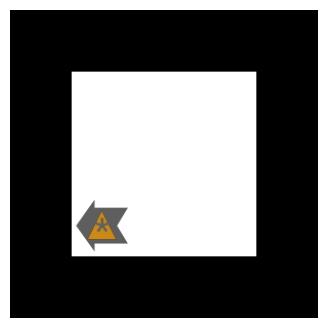

Step: 8
Return so far: 3
Reward from previous action: -1
Instruction: Pick up yellow square
Current observation: [3 1 0 0 0 1 0 1 0 0 0 0 1 1 0 3 1]
Agent is at 3, 1.
yellow triangle at 3, 1. Object in inventory.
Choose action – 0:UP  1:DOWN  2:LEFT  3:RIGHT  4:PICK UP  5:DROP 6:USE


ValueError: invalid literal for int() with base 10: 'q'

In [4]:
# ---- initial reset ----
obs, _ = env.reset()
step = 0
total_reward = 0
last_reward = None          # stores reward from previous step
terminated = truncated = False

layout = infer_obs_layout(
    obs=obs["features"],
    features=hparams["features"],
    n_objs=num_objs,
    n_doors=num_doors,
    n_cnfd_vars=N_CNFD_VARS,
)
door_start_idx = layout["door_start_idx"]
agent_start_idx = layout["agent_start_idx"]

while not (terminated or truncated):
    clear_output(wait=True)

    # -------- show current frame ----------
    frame = env.render_frame()
    show_frame(frame)

    # -------- show textual info -----------
    print(f"Step: {step}")
    print(f"Return so far: {total_reward}")
    if last_reward is not None:
        print(f"Reward from previous action: {last_reward}")
    print(f"Instruction: {obs['instr']}")
    print(f"Current observation: {obs['features']}")
    semantically_interpretable_state(obs=obs["features"], features=hparams["features"], layout=layout)
    
    print("Choose action – 0:UP  1:DOWN  2:LEFT  3:RIGHT  4:PICK UP  5:DROP 6:USE")

    # -------- get action ------------------
    action = int(input("Your action index: ").strip())
    if action not in range(7):
        print("❌  Please enter an integer 0‑6.")
        break   

    # -------- environment step ------------
    next_obs, reward, terminated, truncated, _ = env.step(action)

    # update bookkeeping
    last_reward = reward
    total_reward += reward
    obs = next_obs
    step += 1

# final display
clear_output(wait=True)
frame = env.render_frame()
show_frame(frame)
print("Episode finished.")
print(f"Current observation: {obs}")
print(f"Total steps: {step}   Return: {total_reward}")
obs, _ = env.reset()